# Note on replication

As this is an early experiment, there weren't many thoughts given about replication.

Collected data was produced by `TwitterRunner.kt` in `ssh://git@git.jetbrains.team/kqa/stdlib-profiling.git` repo commit `72a1fcb9717de1b`. Referenced `-raw` and `-jmh` repos are `stdlib-profiling-serialization-twitter-benchmark-*` repos. Commits `d8c74b28d2c48c1e01b` for `-jmh` and `15b7ad4f8fc1e92` for `-raw` (K/Native).

Measured profiles on my machine can be found in `KotlinQA-stdlib_profiling` [shared Google Drive](https://drive.google.com/drive/folders/0AOimUTBuTFo2Uk9PVA)

In [1]:
import jfr_processor.profilelib.*

In [2]:
data class Measurement(
    val platform: String,
    val cycles: Int,
    val sampleInterval: Int,
    val iteration: Int,
    val freqs: Map<String, Int>
    ) {}

In [3]:
import jdk.jfr.consumer.RecordedFrame
import kotlinx.serialization.builtins.MapEntrySerializer

fun load_data(dataPath: String): List<Measurement> =
     walkPath(dataPath)
        .filter { it.endsWith(".jfr") }
        .map { path ->
            val params = path
                .removeSuffix(".jfr")
                .substringAfterLast("/")
                .split(",")
                .map { it.split("=").let { (k, v) -> k to v} }
                .toMap()
            val freq = mutableMapOf<String, Int>()
            println("'" + path + "'")
            lazy_samples(path).toFreq(freq, when (params["platform"]) {
                "jvm" -> ::jvm_get_name
                "native" -> fun(frame: RecordedFrame): String = frame.method.name
                    .let { if (it.startsWith("kfun:"))
                                it.removePrefix("kfun:").replace("#", ".").substringBefore("(")
                           else
                                "weirdo:" + it
                           }
                else -> throw NotImplementedError("Unknown platform: ${params["platform"]}")
            })
            Measurement(
                platform = params["platform"]!!,
                cycles = params["cycles"]!!.toInt(),
                sampleInterval = params["sampleInterval"]!!.toInt(),
                iteration = params["iteration"]!!.toInt(),
                freqs = freq
            )
        }
        .toList()


In [4]:
fun print_tabular(data: Map<Pair<Int, Int>, String>) {
    val cycless = data.keys.map { it.first }.toSet().sorted()
    val sampleIntervals = data.keys.map { it.second }.toSet().sorted()
    sampleIntervals.forEach { print(it); print(" ") }
    println()
    for (cycle in cycless) {
        print("$cycle   ")
        for (sampleInterval in sampleIntervals) {
            print(data[Pair(cycle, sampleInterval)]!!)
        }
        println()
    }
}

In [5]:
fun do_statistics(data: List<Measurement>, f: (List<Measurement>) -> Iterable<Double>): Unit {
    data
        .groupBy { Pair(it.cycles, it.sampleInterval) }
        .mapValues { (_, v) ->
            f(v)
                .toList()
                .let {
                    val mean = it.sum().toDouble() / it.size
                    val variance = it.sumOf { (it - mean).let { it * it } } / it.size
                    val stddev = Math.sqrt(variance)
                    val cv = stddev / mean
                    "%.3f (%.3f)   ".format(mean, cv)
                }
        }
        .let { data ->
            val cycless = data.keys.map { it.first }.toSet().sorted()
            val sampleIntervals = data.keys.map { it.second }.toSet().sorted()
            sampleIntervals.forEach { print(it); print(" ") }
            println()
            for (cycle in cycless) {
                print("$cycle   ")
                for (sampleInterval in sampleIntervals) {
                    print(data[Pair(cycle, sampleInterval)]!!)
                }
                println()
            }
         }
}

In [6]:
val data = load_data("/home/martinzimen/outputStorage/serialization-twitterBM/sampleInterval_and_cycles_variance_measurement")
val new_base_data = load_data("/home/martinzimen/outputStorage/serialization-twitterBM/new_base_with_memory")

'/home/martinzimen/outputStorage/serialization-twitterBM/sampleInterval_and_cycles_variance_measurement/platform=jvm,cycles=5000,sampleInterval=5,iteration=22.jfr'
'/home/martinzimen/outputStorage/serialization-twitterBM/sampleInterval_and_cycles_variance_measurement/platform=jvm,cycles=50000,sampleInterval=100,iteration=109.jfr'
'/home/martinzimen/outputStorage/serialization-twitterBM/sampleInterval_and_cycles_variance_measurement/platform=native,cycles=100000,sampleInterval=5,iteration=9.jfr'
'/home/martinzimen/outputStorage/serialization-twitterBM/sampleInterval_and_cycles_variance_measurement/platform=native,cycles=50000,sampleInterval=1,iteration=20.jfr'
'/home/martinzimen/outputStorage/serialization-twitterBM/sampleInterval_and_cycles_variance_measurement/platform=jvm,cycles=5000,sampleInterval=100,iteration=34.jfr'
'/home/martinzimen/outputStorage/serialization-twitterBM/sampleInterval_and_cycles_variance_measurement/platform=jvm,cycles=100000,sampleInterval=100,iteration=46.jfr

In [15]:
fun jvm_total_samples(it: List<Measurement>): Iterable<Double> = it.filter { it.platform == "jvm" }.map { it.freqs["org.jetbrains.stdlibprofiling.TwitterBenchmark.encodeDecode"]!!.toDouble() }
fun native_total_samples(it: List<Measurement>): Iterable<Double> = it.filter { it.platform == "native" }.map { it.freqs["org.jetbrains.stdlibprofiling.TwitterBenchmark.encodeDecode"]!!.toDouble() }
fun jvm_substring_samples(it: List<Measurement>): Iterable<Double> = it.filter { it.platform == "jvm" }.map { it.freqs.getOrDefault("java.lang.String.substring", 0).toDouble() }
fun native_substring_samples(it: List<Measurement>): Iterable<Double> = it.filter { it.platform == "native" }.map { it.freqs.getOrDefault("weirdo:Kotlin_String_subSequence", 0).toDouble() }
fun ratio(it: List<Measurement>): Iterable<Double> = it.groupBy { it.iteration }.mapNotNull { (_, v) ->
    val jvm = v.filter { it.platform == "jvm" }.singleOrNull()?.freqs?.getOrDefault("java.lang.String.substring", -1)
    val native = v.filter { it.platform == "native" }.singleOrNull()?.freqs?.getOrDefault("weirdo:Kotlin_String_subSequence", -1)
    if (jvm == null || native == null) null
    else if (native == -1) Double.POSITIVE_INFINITY
    else jvm.toDouble() / native.toDouble()
}

In [16]:
do_statistics(data, ::jvm_total_samples)

1 5 10 50 100 
100   9.067 (0.219)   9.200 (0.223)   8.867 (0.198)   9.358 (0.237)   8.675 (0.212)   
500   28.025 (0.077)   28.242 (0.078)   28.450 (0.073)   28.175 (0.072)   28.467 (0.075)   
1000   44.083 (0.066)   44.242 (0.070)   43.908 (0.062)   43.300 (0.062)   44.125 (0.075)   
5000   209.700 (0.058)   209.350 (0.062)   208.300 (0.063)   210.583 (0.057)   209.925 (0.055)   
10000   417.842 (0.061)   416.825 (0.064)   419.292 (0.059)   415.375 (0.054)   415.975 (0.057)   
50000   2059.835 (0.045)   2109.174 (0.059)   2080.042 (0.050)   2092.150 (0.054)   2088.899 (0.056)   
100000   4162.570 (0.049)   4189.769 (0.054)   4121.215 (0.050)   4141.248 (0.050)   4143.934 (0.054)   


In [17]:
do_statistics(data, ::native_total_samples)

1 5 10 50 100 
100   80.071 (0.026)   80.179 (0.026)   79.964 (0.030)   80.143 (0.028)   81.429 (0.079)   
500   394.964 (0.024)   396.571 (0.024)   396.964 (0.025)   396.107 (0.027)   397.321 (0.024)   
1000   789.036 (0.024)   786.250 (0.022)   787.357 (0.024)   794.000 (0.024)   792.000 (0.024)   
5000   3939.107 (0.018)   3954.214 (0.021)   3981.750 (0.022)   3967.143 (0.021)   3935.857 (0.017)   
10000   7911.821 (0.017)   7897.536 (0.017)   7910.286 (0.018)   7960.607 (0.017)   7890.679 (0.016)   
50000   39485.321 (0.009)   39518.036 (0.011)   39457.107 (0.011)   39542.071 (0.011)   39590.821 (0.010)   
100000   78923.259 (0.008)   79184.429 (0.009)   78975.714 (0.008)   79101.214 (0.008)   79197.464 (0.006)   


In [9]:
do_statistics(data, ::jvm_substring_samples)

1 5 10 50 100 
100   0.350 (1.550)   0.450 (1.459)   0.267 (1.794)   0.308 (1.664)   0.433 (1.255)   
500   1.300 (0.976)   1.242 (1.034)   1.333 (1.203)   1.208 (1.125)   1.158 (1.069)   
1000   1.717 (0.749)   1.742 (0.724)   1.708 (0.768)   2.017 (0.686)   1.858 (0.823)   
5000   8.650 (0.350)   8.858 (0.354)   8.117 (0.361)   9.058 (0.367)   8.267 (0.402)   
10000   17.392 (0.257)   17.817 (0.288)   17.792 (0.267)   17.767 (0.252)   17.000 (0.265)   
50000   88.405 (0.182)   89.628 (0.149)   87.267 (0.163)   88.575 (0.165)   87.059 (0.174)   
100000   171.198 (0.160)   177.132 (0.134)   167.231 (0.175)   171.992 (0.157)   173.545 (0.147)   


In [18]:
do_statistics(data, ::native_substring_samples)

1 5 10 50 100 
100   0.179 (2.145)   0.393 (1.572)   0.321 (1.869)   0.143 (2.449)   0.071 (3.606)   
500   1.143 (0.984)   0.750 (1.162)   1.000 (1.069)   1.179 (0.909)   1.321 (0.859)   
1000   2.179 (0.602)   2.143 (0.594)   2.607 (0.427)   2.107 (0.765)   1.679 (0.658)   
5000   9.714 (0.317)   10.071 (0.294)   11.929 (0.346)   10.393 (0.238)   9.464 (0.287)   
10000   21.143 (0.185)   18.750 (0.223)   20.679 (0.260)   20.643 (0.170)   20.500 (0.190)   
50000   105.179 (0.101)   99.393 (0.099)   102.464 (0.115)   102.036 (0.119)   105.643 (0.107)   
100000   205.926 (0.056)   207.643 (0.073)   204.286 (0.063)   202.500 (0.062)   206.286 (0.063)   


In [19]:
do_statistics(data, ::ratio)

1 5 10 50 100 
100   Infinity (NaN)   Infinity (NaN)   Infinity (NaN)   Infinity (NaN)   Infinity (NaN)   
500   Infinity (NaN)   Infinity (NaN)   Infinity (NaN)   Infinity (NaN)   Infinity (NaN)   
1000   Infinity (NaN)   Infinity (NaN)   Infinity (NaN)   Infinity (NaN)   Infinity (NaN)   
5000   1.048 (0.506)   0.967 (0.560)   0.849 (0.568)   0.795 (0.586)   1.043 (0.598)   
10000   0.815 (0.323)   1.045 (0.363)   0.948 (0.388)   0.912 (0.364)   0.847 (0.406)   
50000   0.841 (0.177)   0.928 (0.181)   0.908 (0.173)   0.903 (0.185)   0.858 (0.203)   
100000   0.811 (0.230)   0.856 (0.156)   0.854 (0.165)   0.891 (0.133)   0.856 (0.168)   


I tried to verify these results with the `StringSubstringBenchmark`. Here are the results:

<table border="0" cellspacing="0" cellpadding="0" class="table-ta1"><colgroup><col width="380"/><col width="99"/><col width="20"/><col width="111"/><col width="99"/><col width="45"/><col width="99"/><col width="15"/><col width="99"/><col width="69"/><col width="48"/><col width="99"/><col width="47"/><col width="99"/></colgroup><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>Benchmark</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>JVM</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default"> </td><td style="text-align:left;width:0.9972in; " class="cell-Default"> </td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td><td style="text-align:left;width:0.4098in; " class="cell-Default">
<p>CV</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>Native</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default"> </td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td><td style="text-align:left;width:0.6201in; " class="cell-Default"> </td><td style="text-align:left;width:0.4283in; " class="cell-Default">
<p>CV</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td><td style="text-align:left;width:0.4193in; " class="cell-Default">
<p>Ratio</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p></p>
</td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.big_all</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>621984344.556</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>57011688.479</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.09</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>7672.976</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>58.342</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.01</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.big_none</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>584306253.059</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>57856945.574</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.10</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>31479339.719</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>94988.842</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.05</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.big_none_end</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>569085779.74</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>2412990.634</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>31494388.964</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>12718.71</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.06</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.big_some_100000</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>143394.765</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>1284.902</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.01</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>111956.663</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>3753.041</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.03</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.78</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.big_some_4000</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>3545146.842</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>13713.264</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>2596904.764</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>36224.975</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.01</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.73</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.big_some_4000_end</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>3564383.194</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>15939.015</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>2627941.463</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>30432.023</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.01</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.74</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.big_some_40000</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>363026.766</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>1303.716</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>279441.021</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>1124.098</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.77</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.big_some_40000_end</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>361792.415</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>1965.237</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.01</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>273902.646</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>1117.117</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.76</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.small_all</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>588461813.627</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>46732750.086</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.08</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>25420776.14</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>90142.851</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.04</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.small_none</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>569824468.218</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>13092934.311</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.02</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>31051405.042</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>50668.009</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.00</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.05</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr><tr class="row-ro1"><td style="text-align:left;width:3.4209in; " class="cell-Default">
<p>StringSubstringBenchmark.small_some</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>188870615.7</p>
</td><td style="text-align:left;width:0.1819in; " class="cell-Default">
<p> ±</p>
</td><td style="text-align:right; width:0.9972in; " class="cell-Default">
<p>11988133.984</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default">
<p>  ops/s</p>
</td><td style="text-align:right; width:0.4098in; " class="cell-ce2">
<p>0.06</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>23677559.782</p>
</td><td style="text-align:left;width:0.139in; " class="cell-Default">
<p>±</p>
</td><td style="text-align:right; width:0.889in; " class="cell-Default">
<p>456653.938</p>
</td><td style="text-align:left;width:0.6201in; " class="cell-Default">
<p>ops/sec</p>
</td><td style="text-align:right; width:0.4283in; " class="cell-ce2">
<p>0.02</p>
</td><td style="text-align:left;width:0.889in; " class="cell-ce2"> </td><td style="text-align:right; width:0.4193in; " class="cell-ce2">
<p>0.13</p>
</td><td style="text-align:left;width:0.889in; " class="cell-Default"> </td></tr></table>
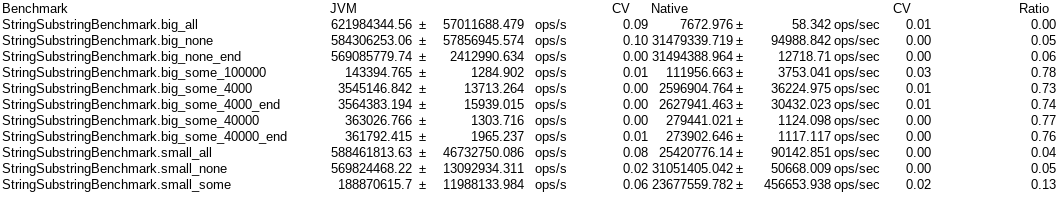

Next, I wanted to disable GC. For that, I needed to increase memory by `-Xmx48g` and `-Xms48g`. However, JVM was still failing. For this reason, I wanted to decrease warmup iterations (`-wi`) from 3 to 1. Then, I measured only for 100 000 cycles and sampling interval 100. This, however, influenced the measurement _a lot_. I suspect the warmup iterations parameter to be the case. Therefore, proper investigation of the effect of `-wi` should be performed.

In [20]:
do_statistics(new_base_data, ::jvm_total_samples)
do_statistics(new_base_data, ::native_total_samples)
do_statistics(new_base_data, ::jvm_substring_samples)
do_statistics(new_base_data, ::native_substring_samples)
do_statistics(new_base_data, ::ratio)

100 
100000   4533.290 (0.040)   
100 
100000   79040.518 (0.007)   
100 
100000   279.326 (0.211)   
100 
100000   203.754 (0.066)   
100 
100000   1.377 (0.221)   
